<a href="https://colab.research.google.com/github/BrunaFerreira/Mestrado_UNIFESP/blob/main/Revisao_5_Perguntas_Respostas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install Unidecode

In [2]:
import pandas as pd
import numpy as np
import re
from unidecode import unidecode
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

In [3]:
def clean_text(df, col):
    chars_to_remove = r"[.\-()/]"

    df[col] = (
        df[col]
        .fillna("")                    # evita transformar NaN em "nan"
        .astype(str)
        .map(unidecode)
        .str.lower()
        .str.replace(chars_to_remove, " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return df

#**Base Completa de Artigos**

In [4]:
path = '/content/drive/MyDrive/0_Mestrado_unifesp/3_Pesquisa/Revisao/202607_Revisao_Completa/'
df  = pd.read_csv(path + '2_Perguntas_Pesquisa/3_Lista_Final_Artigos_Revisao_202607.csv')

# Excluindo artigos de revisão
df = df[df['Questao_18']!='Sim']

df.shape

(135, 23)

In [5]:
TOTAL_ARTIGOS = 135

# **Questões 1 e 2**



```
1. Quais conjuntos de dados foram considerados?

2. Qual tipo de dado foi usado (Raio X, Tomografia, etc.)?

```



## **Preparação Base de Dados**






In [6]:
Q1 = df.loc[:, ["DOI", "Nome_A", "Questao_6"]].copy()
Q1 = clean_text(Q1, "Questao_6")

Q1.loc[
    Q1["DOI"].isin([
        "10.1109/ISBI56570.2024.10635870",
        "10.1109/ICIST59754.2023.10367148"
    ]),
    "Q6"
] = "fotografia"

In [7]:
texto = Q1["Questao_6"].fillna("").astype("string")
padroes = {
    "RM": r"\b(spy1|spy2|tcia breast|duke breast|brats18|roco radiology|ucsf pdgm|scgm|mri|ressonancia\w*)\b",
    "RX": r"\b(cbis ddsm|x ray|cxr|covid 19|ffdm|roco radiology|mimic cxr|x de torax|radiogr\w*|rx|.*chexpert.*|nih chestx|mammograph\w*|mamograf\w*|raio\s*x)\b",
    "TC": r"\b(roco radiology|ct|tc|tomograf\w*)\b",
    #"Salivares": r"\b(submandibulares\w*|parotida\w*|sd 128|sd 198|sd 260|salivar\w*)\b",
    "Clinico": r"\b(oasis|phantoms|diabetes|.*ph2.*|spy2|spy1|tcia breast|duke breast|cbis ddsm|,*bcn20000.*|meps|medicos de imagem|clinicos|nhanes|.*pad ufes 20.*|bfw|fairface|utkface|metadados|atributos dos pacientes|ffhq flickr|brats18|mimic cxr|mimic|uci heart disease|chexpert|idade|sexo|raca|genero|income|dados tabulares|anotacoes manuais|dados clinic\w*|tcga brca|de sangue|demografic\w*)\b",
    "USG": r"\b(roco radiology|ultrasound|usg|ultrassom|ultrassonog\w*)\b",
    "Dermatologicas": r"\b(.*ph2.*|.*skinl2.*|.*snu.*|.*med node.*|.*dermnet.*|.*medhybridequity.*|.*pipsqueak.*|.*bcn20000.*|pele|.*pad ufes 20.*|hematomas|isic20\w*|isic|ham10000|.*fitz\w*|dermat\w*)\b",
    "Histologico": r"\b(ivcm|breakhis|btm|tcga brca|histop\w*|histolog\w*|biopsi\w*)\b",
    "Sinteticos": r"\b(.*hybridequity.*|.*syntheticdarker.*|sintetic\w*)\b",
    "Fotografias": r"\b(imagens de satelite|oasis|swedish world culture|architectural heritage|ff++|waterbirds|celeba|imagens medicas multi|medicos de imagem|bfw|utkface|fairface|ffhq flickr|utk face|papila|hematomas|pacs|minidomainnet|hyper kvasir|fotog\w*|trigo|goiaba|rostos|fotos|mascaras de segmentacao\w*)\b",
    "Oftalmologicas": r"\b(sokl|as oct nc|retinal|disco optico|glaucoma|ivcm|cornea|aptos2019|olho\w*|oftalmo\w*)\b",
    "Outros": r"\b(podcast|law school|german credit|adult dataset|bank|default|adult|literatura biomedica|swedish world culture|architectural heritage|hatexplain|twitter|dfdc|dfd|celeb|ff++|mnist|podcast|dados multimodais|hyper kvasir|movie|audio\w*)\b",
}

for coluna, padrao in padroes.items():
    # Converte (...) em (?:...), preservando grupos especiais como (?=...)
    padrao_sem_captura = re.sub(
        r"(?<!\\)\((?!\?)",
        "(?:",
        padrao,
    )

    Q1.loc[:, coluna] = (
        texto.str.contains(
            padrao_sem_captura,
            regex=True,
            case=False,
            na=False,
        )
        .astype("int8")
    )

pd.set_option("display.max_colwidth", None)

## **Grafico 1**

In [8]:
Q1_graf = Q1[['Clinico','RM','USG', 'RX', 'TC',"Dermatologicas",'Oftalmologicas','Histologico','Fotografias','Sinteticos','Outros']]
colunas = 'Dados Clinicos','Ressonância','Ultrassonografia','Raio-X', 'Tomografia',"Dermatológica",'Oftalmológica','Histopatológico','Fotografia', 'Sintético','Outros'
Q1_graf.columns = colunas
resumo = (
    Q1_graf
    .sum()
    .rename("Total")
    .reset_index()
    .rename(columns={"index": "Categoria"})
)
resumo["Percentual"] = (resumo["Total"] / TOTAL_ARTIGOS * 100).round(1)
resumo = resumo.sort_values("Total", ascending=False)
resumo

,Categoria,Total,Percentual
0,Dados Clinicos,63,46.7
3,Raio-X,40,29.6
5,Dermatológica,28,20.7
8,Fotografia,27,20.0
1,Ressonância,17,12.6
10,Outros,14,10.4
6,Oftalmológica,14,10.4
2,Ultrassonografia,12,8.9
4,Tomografia,11,8.1
7,Histopatológico,10,7.4


### **Export Grafico**

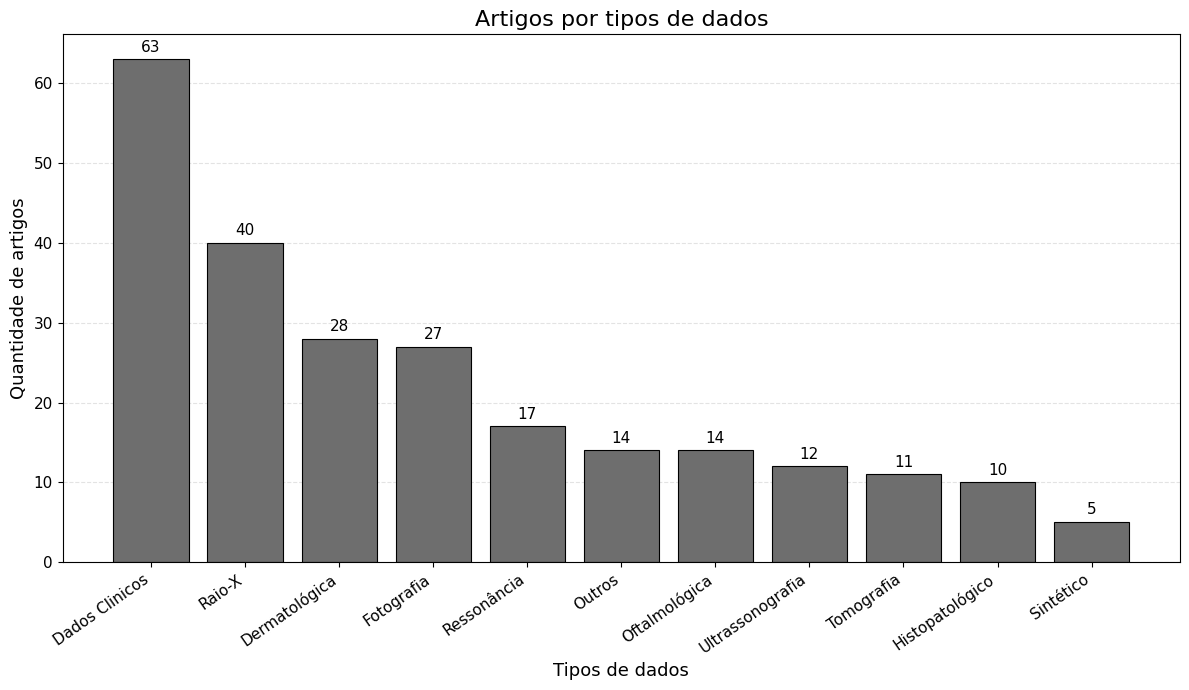

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

bars = plt.bar(
    resumo["Categoria"],
    resumo["Total"],
    color="#6e6e6e",
    edgecolor="black",
    linewidth=0.8
)

plt.title("Artigos por tipos de dados", fontsize=16)
plt.xlabel("Tipos de dados", fontsize=13)
plt.ylabel("Quantidade de artigos", fontsize=13)

plt.xticks(rotation=35, ha="right", fontsize=11)
plt.yticks(fontsize=11)

# Grade
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

plt.gca().set_axisbelow(True)

# Exibir os valores sobre as barras
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.6,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

# Salvar figura
plt.savefig(
    path+"3_Graficos_Tabelas/imagens/Q1_grafico.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()

## **Tipos de Dados**

### **Dados Clinicos**

In [10]:
Q1_clinico = Q1[Q1['Clinico']==1]
Q1_clinico[['DOI', 'Nome_A', 'Questao_6', 'Clinico']].head(50)


,DOI,Nome_A,Questao_6,Clinico
0,10.1007/978-981-97-7679-5_1,CLASSIFICATION OF GOUGEROT SJOGREN SYNDROME BASED ON ARTIFICIAL INTELLIGENCE,"imagens de ultrassonografia das glandulas salivares base de dados harmonicss base de dados gsid anotacoes de especialistas dados clinicos scores de vita, omeract, eular",1
1,10.1016/j.jtos.2024.08.002,DEEP LEARNING BASED ANALYSIS OF IN VIVO CONFOCAL MICROSCOPY IMAGES OF THE SUBBASAL CORNEAL NERVE PLEXUS' INFERIOR WHORL IN PATIENTS WITH NEUROPATHIC CORNEAL PAIN AND DRY EYE DISEASE,dados clinicos e imagens obtidas por microscopia confocal in vivo ivcm,1
2,10.1038/s41598-023-42719-5,APPLICATION OF SERUM SERS TECHNOLOGY COMBINED WITH DEEP LEARNING ALGORITHM IN THE RAPID DIAGNOSIS OF IMMUNE DISEASES AND CHRONIC KIDNEY DISEASE,amostras de sangue espectros sers surface enhanced raman spectroscopy dados demograficos dados gerados,1
5,10.1007/s10067-025-07518-5,ARTIFICIAL INTELLIGENCE BASED PREDICTION OF ORGAN INVOLVEMENT IN SJOGREN'S SYNDROME USING LABIAL GLAND BIOPSY WHOLE SLIDE IMAGES,imagens de laminas inteiras wsi de biopsia de glandula labial patches extraidos das wsi dados clinicos dos pacientes envolvimento de orgaos,1
13,10.1186/s41927-024-00417-3,CLASSIFICATION OF SALIVARY GLAND BIOPSIES IN SJOGREN'S SYNDROME BY A CONVOLUTIONAL NEURAL NETWORK USING AN AUTO MACHINE LEARNING PLATFORM,"1 dados clinicos e demograficos: idade e genero dos pacientes diagnostico previo de condicoes autoimunes sistemicas associadas manifestacoes extraglandulares, como: envolvimento neurologico envolvimento pulmonar envolvimento renal 2 dados imunologicos: positividade de anticorpos especificos: anti ro ssa anti la ssb fator reumatoide rf anticorpos antinucleares ana outros marcadores de inflamacao imunologica 3 dados histopatologicos: biopsias de glandulas salivares menores, com imagens analisadas apos coloracao por: hematoxilina eosina h&e : para visualizar a arquitetura do tecido cd3: para marcar linfocitos t focus score fs : numero de focos linfocitarios por 4 mm2 de tecido glandular, onde: fs >= 1 indica infiltracao linfocitica, sendo sugestivo de sindrome de sjogren fs < 1 indica histologia normal outras caracteristicas histologicas, como: atrofia glandular fibrose intersticial dilatacao ductal lesoes linfoepiteliais",1
15,10.1038/s41598-024-75925-w,A DEEP LEARNING BASED ASSISTED ANALYSIS APPROACH FOR SJOGREN'S SYNDROME PATHOLOGY IMAGES,"1 dados histologicos, biopsias de glandulas salivares menores 2 anotacoes manuais: linfocitos",1
18,10.1007/s10103-024-04078-z,RESEARCH ON DISEASE DIAGNOSIS BASED ON TEACHER STUDENT NETWORK AND RAMAN SPECTROSCOPY,exames de sangue exames de urina proteinas lipideos aminoacidos carotenoides colesterol,1
20,10.1371/journal.pdig.0000918,RACIAL DISPARITIES IN CONTINUOUS GLUCOSE MONITORING BASED 60 MIN GLUCOSE PREDICTIONS AMONG PEOPLE WITH TYPE 1 DIABETES,dados de monitoramento continuo de glicose cgm idade sexo raca brancos nao hispanicos e negros nao hispanicos tamanho do conjunto de treino,1
22,10.1016/j.asoc.2024.112133,WEARING MYOPIA GLASSES ON GANS: MITIGATING BIAS FOR PRE TRAINED GENERATIVE ADVERSARIAL NETWORKS VIA ONLINE PRIOR PERTURBATION,dados tabulares estruturados,1
24,10.1145/3351095.3372839,FAIRNESS WARNINGS AND FAIR MAML: LEARNING FAIRLY WITH MINIMAL DATA,"radiografias de torax, sexo e idade",1


### **Dados Histologicos**

In [11]:
Q1_hist = Q1[Q1['Histologico']==1]
Q1_hist[['DOI', 'Nome_A', 'Questao_6', 'Histologico']].tail(50)

,DOI,Nome_A,Questao_6,Histologico
1,10.1016/j.jtos.2024.08.002,DEEP LEARNING BASED ANALYSIS OF IN VIVO CONFOCAL MICROSCOPY IMAGES OF THE SUBBASAL CORNEAL NERVE PLEXUS' INFERIOR WHORL IN PATIENTS WITH NEUROPATHIC CORNEAL PAIN AND DRY EYE DISEASE,dados clinicos e imagens obtidas por microscopia confocal in vivo ivcm,1
5,10.1007/s10067-025-07518-5,ARTIFICIAL INTELLIGENCE BASED PREDICTION OF ORGAN INVOLVEMENT IN SJOGREN'S SYNDROME USING LABIAL GLAND BIOPSY WHOLE SLIDE IMAGES,imagens de laminas inteiras wsi de biopsia de glandula labial patches extraidos das wsi dados clinicos dos pacientes envolvimento de orgaos,1
9,10.1186/s13000-026-01756-0,SJOGREN'S SYNDROME FOCUSASSIST: LYMPHOCYTIC FOCUS ASSESSMENT IN SJOGREN'S SYNDROME: A DEEP LEARNING AND SPATIAL ANALYSIS APPROACH,laminas histopatologicas coradas com h&e biopsias de glandulas salivares labiais imagens digitais de laminas whole slide images wsi secoes patches de imagem 512x512 pixels anotacoes celulares nivel de linfocitos anotacoes de lesoes nivel de focos linfociticos resultados de exames laboratoriais imunologicos dos pacientes,1
11,10.1016/j.jaut.2025.103418,EVALUATION OF MINOR LABIAL SALIVARY GLAND FOCUS SCORE IN SJOGREN'S DISEASE USING DEEP LEARNING: A TOOL FOR MORE EFFICIENT DIAGNOSIS AND FUTURE TISSUE BIOMARKER DISCOVERY,biopsias de glandulas salivares labiais menores imagens histopatologicas,1
13,10.1186/s41927-024-00417-3,CLASSIFICATION OF SALIVARY GLAND BIOPSIES IN SJOGREN'S SYNDROME BY A CONVOLUTIONAL NEURAL NETWORK USING AN AUTO MACHINE LEARNING PLATFORM,"1 dados clinicos e demograficos: idade e genero dos pacientes diagnostico previo de condicoes autoimunes sistemicas associadas manifestacoes extraglandulares, como: envolvimento neurologico envolvimento pulmonar envolvimento renal 2 dados imunologicos: positividade de anticorpos especificos: anti ro ssa anti la ssb fator reumatoide rf anticorpos antinucleares ana outros marcadores de inflamacao imunologica 3 dados histopatologicos: biopsias de glandulas salivares menores, com imagens analisadas apos coloracao por: hematoxilina eosina h&e : para visualizar a arquitetura do tecido cd3: para marcar linfocitos t focus score fs : numero de focos linfocitarios por 4 mm2 de tecido glandular, onde: fs >= 1 indica infiltracao linfocitica, sendo sugestivo de sindrome de sjogren fs < 1 indica histologia normal outras caracteristicas histologicas, como: atrofia glandular fibrose intersticial dilatacao ductal lesoes linfoepiteliais",1
15,10.1038/s41598-024-75925-w,A DEEP LEARNING BASED ASSISTED ANALYSIS APPROACH FOR SJOGREN'S SYNDROME PATHOLOGY IMAGES,"1 dados histologicos, biopsias de glandulas salivares menores 2 anotacoes manuais: linfocitos",1
27,10.25258/ijddt.16.12s.66,NEXT GENERATION RADIOGENOMICS: ADVANCED DIAGNOSTICS FOR EARLY BREAST CANCER DETECTION AND PERSONALIZED RISK STRATIFICATION,cbis ddsm mammografia breakhis histopatologia,1
76,10.1109/EMBC53108.2024.10782012,ENSURING MODEL FAIRNESS VIA STRATIFIED TRAINING: TP53 MUTATION PREDICTION WITH ESTROGEN RECEPTOR STRATIFICATION IN BREAST HISTOPATHOLOGY,tcga brca the cancer genome atlas breast cancer imagens histopatologicas de mama,1
78,10.1109/TMI.2025.3641192,EXPERT LIKE REPARAMETERIZATION OF HETEROGENEOUS PYRAMID RECEPTIVE FIELDS IN EFFICIENT CNNS FOR FAIR MEDICAL IMAGE CLASSIFICATION,"aptos2019, isic2018, btm, as oct nc",1
132,10.18280/isi.310313,"CRITICAL ASSESSMENT OF DCGAN BASED DATA BALANCING IN DEEP LEARNING FOR KERATITIS IDENTIFICATION: TRADE OFF BETWEEN FIDELITY, FAIRNESS, AND PERFORMANCE",imagens de microscopia confocal in vivo ivcm da cornea imagens sinteticas geradas por dcgan gan para balanceamento das classes,1


### **Usg**

In [12]:
Q = Q1[Q1['USG']==1]
Q[['DOI', 'Nome_A', 'Questao_6','USG']].head(12)

,DOI,Nome_A,Questao_6,USG
0,10.1007/978-981-97-7679-5_1,CLASSIFICATION OF GOUGEROT SJOGREN SYNDROME BASED ON ARTIFICIAL INTELLIGENCE,"imagens de ultrassonografia das glandulas salivares base de dados harmonicss base de dados gsid anotacoes de especialistas dados clinicos scores de vita, omeract, eular",1
3,10.1016/j.bspc.2026.109615,DIAGNOSTIC PERFORMANCE OF DEEP LEARNING MODELS USING PAROTID GLAND ULTRASONOGRAPHY IN SJOGREN'S DISEASE,imagens de ultrassonografia das glandulas parotidas,1
6,10.1259/dmfr.20190348,USEFULNESS OF A DEEP LEARNING SYSTEM FOR DIAGNOSING SJOGREN'S SYNDROME USING ULTRASONOGRAPHY IMAGES,imagens de ultrassom us das glandulas salivares,1
7,10.3390/bioengineering10111283,MACHINE AND DEEP LEARNING APPROACHES APPLIED TO CLASSIFY GOUGEROT SJOGREN SYNDROME AND JOINTLY SEGMENT SALIVARY GLANDS,dados de imagens de ultrassom us das glandulas salivares devita 0 3 : classifica a morfologia das glandulas omeract 0 3 : avalia a severidade das glandulas afetadas eular: baseado em fatores como inflamacao linfocitica e producao de anticorpos anti ssa ro,1
8,10.1109/BIBE52308.2021.9635506,SCORING PRIMARY SJOGREN'S SYNDROME AFFECTED SALIVARY GLANDS ULTRASONOGRAPHY IMAGES BY USING DEEP LEARNING ALGORITHMS,1 dados principais: imagens de ultrassom das glandulas salivares 2 rotulos: escoragem clinica baseada em padroes de referencia estabelecidos,1
12,10.3390/jcm10194508,PRELIMINARY STUDY ON THE DIAGNOSTIC PERFORMANCE OF A DEEP LEARNING SYSTEM FOR SUBMANDIBULAR GLAND INFLAMMATION USING ULTRASONOGRAPHY IMAGES,imagens de ultrassom das glandulas submandibulares,1
14,10.1016/j.compbiomed.2020.104154,DEEP LEARNING SEGMENTATION OF PRIMARY SJOGREN'S SYNDROME AFFECTED SALIVARY GLANDS FROM ULTRASONOGRAPHY IMAGES,imagens de ultrassom us das glandulas salivares,1
16,10.1109/AICCSA63423.2024.10912538,A DEEP LEARNING APPROACH FOR SALIVARY GLAND ECHOGRAPHIC IMAGE ANALYSIS IN SJOGREN'S SYNDROME DETECTION,imagens ultrassonograficas ecograficas das glandulas salivares,1
17,10.1093/rheumatology/keae312,DEEP LEARNING IN THE PRECISE ASSESSMENT OF PRIMARY SJOGREN'S SYNDROME BASED ON ULTRASOUND IMAGES,ultrasound images,1
126,10.1117/12.3046450,FAIR TEXT TO MEDICAL IMAGE DIFFUSION MODEL WITH SUBGROUP DISTRIBUTION ALIGNED TUNING,roco radiology objects in context brats18 brain tumor segmentation challenge 2018,1


### **Oftalmologicas**

In [13]:
Q1_oftalmo = Q1[Q1['Oftalmologicas']==1]
Q1_oftalmo[['DOI', 'Nome_A', 'Questao_6', 'Oftalmologicas']].head(50)

,DOI,Nome_A,Questao_6,Oftalmologicas
1,10.1016/j.jtos.2024.08.002,DEEP LEARNING BASED ANALYSIS OF IN VIVO CONFOCAL MICROSCOPY IMAGES OF THE SUBBASAL CORNEAL NERVE PLEXUS' INFERIOR WHORL IN PATIENTS WITH NEUROPATHIC CORNEAL PAIN AND DRY EYE DISEASE,dados clinicos e imagens obtidas por microscopia confocal in vivo ivcm,1
4,10.3390/diagnostics13142373,DETECTION OF HYDROXYCHLOROQUINE RETINOPATHY VIA HYPERSPECTRAL AND DEEP LEARNING THROUGH OPHTHALMOSCOPE IMAGES,imagens oftalmoscopicas hiperespectrais,1
40,10.1002/ima.23003,DEEP LEARNING BASED GLAUCOMA NETWORK CLASSIFICATION GNC USING RETINAL IMAGES,"imagens da retina, dados de fundoscopia, focando no disco optico e caracteristicas associadas ao glaucoma",1
66,10.1016/j.procs.2025.04.469,DIABETIC RETINOPATHY DETECTION USING SMARTPHONE FUNDOSCOPY: ADVANCING HEALTHCARE EQUITY THROUGH INTELLIGENT EDGE COMPUTING,retinal images fundoscopic images aptos 2019 dataset,1
78,10.1109/TMI.2025.3641192,EXPERT LIKE REPARAMETERIZATION OF HETEROGENEOUS PYRAMID RECEPTIVE FIELDS IN EFFICIENT CNNS FOR FAIR MEDICAL IMAGE CLASSIFICATION,"aptos2019, isic2018, btm, as oct nc",1
88,-1,FAIRSEG: A LARGE SCALE MEDICAL IMAGE SEGMENTATION DATASET FOR FAIRNESS LEARNING USING SEGMENT ANYTHING MODEL WITH FAIR ERROR BOUND SCALING,"imagens de fundo de olho slo fundus imaging mascaras de segmentacao idade genero masculino feminino raca asiatico, negro afro americano, branco caucasiano etnia hispanico nao hispanico lingua preferida ingles, espanhol, outros estado civil casado, solteiro, divorciado, viuvo, etc",1
90,10.1007/978-3-031-73116-7_15,FAIRDOMAIN: ACHIEVING FAIRNESS IN CROSS DOMAIN MEDICAL IMAGE SEGMENTATION AND CLASSIFICATION,en face fundus images slo fundus images imagens oct para geracao de anotacoes mascaras de segmentacao cup e disc dados demograficos dos pacientes diagnostico de glaucoma,1
111,10.1002/ird3.101,FAIRNESS IN ARTIFICIAL INTELLIGENCE DRIVEN MULTI ORGAN IMAGE SEGMENTATION,"mimic cxr, chestx ray8 e chexpert: radiografias de torax para diagnostico de doencas pulmonares kits 2019: tomografias computadorizadas para segmentacao de rins e tumores brats 2018: imagens de ressonancia magnetica para segmentacao de tumores cerebrais isic e bases privadas: imagens de dermatoscopia para diagnostico de doencas de pele tcia e btcv: tomografias abdominais para segmentacao multi orgao dados privados de ressonancia magnetica e imagens de fundo de olho: segmentacao de prostata e retina",1
114,-1,FAIRTUNE: OPTIMIZING PARAMETER EFFICIENT FINE TUNING FOR FAIRNESS IN MEDICAL IMAGE ANALYSIS,"imagens medicas: imagens como radiografias, imagens de fundo de olho, e dermatoscopicas atributos sensiveis: idade, genero, etnia, tipo de pele como no fitzpatrick17k rotulos de diagnostico: classificacao binaria de doencas, como benigno vs maligno",1
132,10.18280/isi.310313,"CRITICAL ASSESSMENT OF DCGAN BASED DATA BALANCING IN DEEP LEARNING FOR KERATITIS IDENTIFICATION: TRADE OFF BETWEEN FIDELITY, FAIRNESS, AND PERFORMANCE",imagens de microscopia confocal in vivo ivcm da cornea imagens sinteticas geradas por dcgan gan para balanceamento das classes,1


### **Dermatologicas**

In [14]:
Q1_dermato = Q1[Q1['Dermatologicas']==1]
Q1_dermato[['DOI', 'Nome_A', 'Questao_6', 'Dermatologicas']].head(50)

,DOI,Nome_A,Questao_6,Dermatologicas
57,10.1109/GCAT66372.2025.11368593,MULTI CLASS SKIN DISEASE CLASSIFICATION USING DEEP CONVOLUTIONAL NEURAL NETWORKS AND AI,"ham10000, isic challenge repositories, bcn20000, pad ufes 20, fitzpatrick17k",1
63,10.3390/s26103215,EVALUATION FRAMEWORK FOR BRUISE DETECTION: SYSTEMATIC ALS WHITE LIGHT TRAINING AND SKIN TONE BALANCING WITH DEEP LEARNING,imagens de hematomas em luz branca white light imagens de hematomas com fonte de luz alternativa als em 415 nm imagens de hematomas com fonte de luz alternativa als em 450 nm imagens com filtro laranja imagens com filtro amarelo anotacoes bounding boxes e segmentacoes feitas por multiplos anotadores com consenso completo rotulos de tom de pele skin tone,1
67,10.1016/j.jocs.2026.102849,REASONING ON THE GAP BETWEEN SYNTHETIC AND AUTHENTIC DIVERSITY: THE LIMITS OF COMPUTATIONAL SOLUTIONS TO REPRESENTATION BIAS,ham10000 pipsqueak ham syntheticdarker ham hybridequity isic archive dermnet fitzpatrick17k pad ufes 20 bcn20000 med node skinl2 snu ph2,1
74,10.1016/j.media.2025.103764,BIASPRUNER: MITIGATING BIAS TRANSFER IN CONTINUAL LEARNING FOR FAIR MEDICAL IMAGE ANALYSIS,fitzpatrick17k fitz ham10000 ham nih chestx ray14 nih,1
78,10.1109/TMI.2025.3641192,EXPERT LIKE REPARAMETERIZATION OF HETEROGENEOUS PYRAMID RECEPTIVE FIELDS IN EFFICIENT CNNS FOR FAIR MEDICAL IMAGE CLASSIFICATION,"aptos2019, isic2018, btm, as oct nc",1
81,10.1007/978-3-032-04981-0_22,EXPOSING AND MITIGATING CALIBRATION BIASES AND DEMOGRAPHIC UNFAIRNESS IN MLLM FEW SHOT IN CONTEXT LEARNING FOR MEDICAL IMAGE CLASSIFICATION,"papila, ham10000, mimic cxr",1
83,-1,EVALUATING THE FAIRNESS OF DEEP LEARNING UNCERTAINTY ESTIMATES IN MEDICAL IMAGE ANALYSIS,imagens medicas dermatoscopia e ressonancia magnetica dados clinicos e demograficos idade dos pacientes diferentes modalidades de aprendizado de maquina: classificacao cancer de pele segmentacao tumores cerebrais regressao doenca de alzheimer atributos sensiveis para fairness: idade e volume do tumor,1
94,10.1007/978-3-031-43898-1_10,TOWARD FAIRNESS THROUGH FAIR MULTI EXIT FRAMEWORK FOR DERMATOLOGICAL DISEASE DIAGNOSIS,imagens clinicas de doencas da pele diagnostico da lesao confirmacao medica genero na base isic 2019 tom de pele na base fitzpatrick 17k,1
100,10.1007/978-3-031-43898-1_43,DATA AUDIT: IDENTIFYING ATTRIBUTE UTILITY AND DETECTABILITY INDUCED BIAS IN TASK MODELS,os dados considerados no estudo foram: imagens dermatoscopicas tipo de lesao fonte dos dados fitzpatrick skin scale tom de pele do paciente presenca de regua dermatoscopica artefato que pode influenciar a predicao do modelo marcador de gentiana tinta azul usada para marcacao clinica da lesao,1
102,10.1109/TCSVT.2025.3603409,FADIAFRAME: IMPROVING FAIRNESS AND ACCURACY OF DEEP LEARNING BASED DIAGNOSIS FOR DERMATOLOGICAL LESIONS VIA A NOVEL POST PROCESSING FRAMEWORK,imagens dermatoscopicas,1


### **Ressonancia**

In [15]:
Q = Q1[Q1['RM']==1]
Q[['DOI', 'Nome_A', 'Questao_6', 'RM']].head(50)

,DOI,Nome_A,Questao_6,RM
44,10.3233/FAIA240769,TRANSFER LEARNING CAN INTRODUCE BIAS,oasis open access series of imaging studies ; imagens de ressonancia magnetica cerebral mri ; dados demograficos idade e sexo,1
60,10.1007/978-3-032-23176-5_13,A SYSTEMATIC MACHINE LEARNING APPROACH FOR BRAIN TUMOR CLASSIFICATION THROUGH SYNTHETIC CONTROL DATA GENERATION TO PREVENT BIAS AND ENSURE FAIRNESS IN PREDICTIVE MODELS USING MRI IMAGING,"brats 2023 adult glioma dataset amostras sinteticas de pacientes sem tumor geradas a partir do brats 2021 imagens de mri nas modalidades: t1n, t2w, t1c e t2f flair mascaras de segmentacao com rotulos anatomicos tumorais 0, 1, 2, 3 e 4 para geracao sintetica",1
64,10.1007/978-3-032-05559-0_31,ON TACKLING DOMAIN SHIFT IN BREAST MRI USING ONLY PUBLICLY AVAILABLE DATA: REPRODUCIBLE BREAST CANCER SEGMENTATION AND PCR PREDICTION,duke breast cancer mri dataset tcia breast mri collections i spy1 trial dataset i spy2 trial dataset,1
77,10.1016/j.media.2025.103529,AI BASED ASSOCIATION ANALYSIS FOR MEDICAL IMAGING USING LATENT SPACE GEOMETRIC CONFOUNDER CORRECTION,imagens sinteticas 2d circulos elos imagens 3d de faces malha facial imagens de ressonancia magnetica cerebral mri mapas de substancia cinzenta,1
83,-1,EVALUATING THE FAIRNESS OF DEEP LEARNING UNCERTAINTY ESTIMATES IN MEDICAL IMAGE ANALYSIS,imagens medicas dermatoscopia e ressonancia magnetica dados clinicos e demograficos idade dos pacientes diferentes modalidades de aprendizado de maquina: classificacao cancer de pele segmentacao tumores cerebrais regressao doenca de alzheimer atributos sensiveis para fairness: idade e volume do tumor,1
85,-1,EVALUATING THE IMPACT OF MEDICAL IMAGE RECONSTRUCTION ON DOWNSTREAM AI FAIRNESS AND PERFORMANCE,ucsf pdgm ressonancia magnetica cerebral mri de glioma chexpert radiografias de torax chest x ray,1
110,10.1007/978-3-032-05559-0_6,DIVERGENCE AWARE TRAINING WITH AUTOMATIC SUBGROUP MITIGATION FOR BREAST TUMOR SEGMENTATION,"dce mri ressonancia magnetica com contraste dinamico metadados clinicos idade, estado menopausal, densidade mamaria",1
111,10.1002/ird3.101,FAIRNESS IN ARTIFICIAL INTELLIGENCE DRIVEN MULTI ORGAN IMAGE SEGMENTATION,"mimic cxr, chestx ray8 e chexpert: radiografias de torax para diagnostico de doencas pulmonares kits 2019: tomografias computadorizadas para segmentacao de rins e tumores brats 2018: imagens de ressonancia magnetica para segmentacao de tumores cerebrais isic e bases privadas: imagens de dermatoscopia para diagnostico de doencas de pele tcia e btcv: tomografias abdominais para segmentacao multi orgao dados privados de ressonancia magnetica e imagens de fundo de olho: segmentacao de prostata e retina",1
115,10.1109/JBHI.2025.3588196,MITIGATING DATA BIAS IN HEALTHCARE AI WITH SELF SUPERVISED STANDARDIZATION,"imagens medicas mri, ct, x ray datasets de imagens medicas multi institucionais",1
116,10.1016/j.ebiom.2024.105047,DROP THE SHORTCUTS: IMAGE AUGMENTATION IMPROVES FAIRNESS AND DECREASES AI DETECTION OF RACE AND OTHER DEMOGRAPHICS FROM MEDICAL IMAGES,radiografias de torax cxr e imagens de ressonancia magnetica mri,1


### **Raio X**

In [16]:
Q = Q1[Q1['RX']==1]
Q[['DOI', 'Nome_A', 'Questao_6', 'RX']].tail(50)

,DOI,Nome_A,Questao_6,RX
24,10.1145/3351095.3372839,FAIRNESS WARNINGS AND FAIR MAML: LEARNING FAIRLY WITH MINIMAL DATA,"radiografias de torax, sexo e idade",1
25,10.1007/978-3-032-05185-1_3,BIAS AND GENERALIZABILITY OF FOUNDATION MODELS ACROSS DATASETS IN BREAST MAMMOGRAPHY,cbis ddsm rsna screening mammography dataset inbreast mias cmmd vindr mammo cdd cesm kau bcmd mmd mammogram mastery dataset lbmd lebanese breast mammography dataset,1
27,10.25258/ijddt.16.12s.66,NEXT GENERATION RADIOGENOMICS: ADVANCED DIAGNOSTICS FOR EARLY BREAST CANCER DETECTION AND PERSONALIZED RISK STRATIFICATION,cbis ddsm mammografia breakhis histopatologia,1
32,10.1109/EMBC53108.2024.10782563,IMPROVING FAIRNESS IN CHEST X RAY INTERPRETATION MODELS USING ATTENTION DRIVEN MASKED IMAGE MODELING,mimic cxr dataset imagens de raio x de torax chest x ray cxr,1
37,10.1109/ACCESS.2020.3005987,JOINT TRANSFER OF MODEL KNOWLEDGE AND FAIRNESS OVER DOMAINS USING WASSERSTEIN DISTANCE,radiografias de torax,1
42,10.1038/s41598-024-56478-4,IDENTIFICATION OF KIDNEY STONES IN KUB X RAY IMAGES USING VGG16 EMPOWERED WITH EXPLAINABLE ARTIFICIAL INTELLIGENCE,imagens de raio x kub,1
50,10.1007/978-981-96-0348-0_11,IMPROVING INTERSECTIONAL GROUP FAIRNESS USING CONDITIONAL GENERATIVE ADVERSARIAL NETWORK AND TRANSFER LEARNING,nhanes national health and nutrition examination survey covid 19 dataset,1
51,10.1186/s12911-025-02862-7,MITIGATING BIAS IN AI MORTALITY PREDICTIONS FOR MINORITY POPULATIONS: A TRANSFER LEARNING APPROACH,covid 19 case surveillance restricted access detailed data cdc,1
59,10.1145/3306618.3314236,FAIR TRANSFER LEARNING WITH MISSING PROTECTED ATTRIBUTES,"radiografias de torax, sexo e idade",1
61,10.1007/s10140-022-02019-3,DEEP LEARNING PREDICTION OF SEX ON CHEST RADIOGRAPHS: A POTENTIAL CONTRIBUTOR TO BIASED ALGORITHMS,radiografias de torax,1


### **Tomografias**

In [17]:
Q = Q1[Q1['TC']==1]
Q[['DOI', 'Nome_A', 'Questao_6', 'TC']].head(50)

,DOI,Nome_A,Questao_6,TC
10,10.1259/dmfr.20190019,PRELIMINARY STUDY ON THE APPLICATION OF DEEP LEARNING SYSTEM TO DIAGNOSIS OF SJOGREN'S SYNDROME ON CT IMAGES,tomografia computadorizada ct,1
52,10.58496/MJBD/2025/015,SHARED GENERATOR BASED SERVERLESS MULTIMODAL FEDERATED LEARNING FOR MEDICAL IMAGE ANALYSIS,imagens medicas multimodais tomografias computadorizadas ct de pulmao,1
73,10.1016/j.artmed.2024.102936,TACKLING HETEROGENEITY IN MEDICAL FEDERATED LEARNING VIA ALIGNING VISION TRANSFORMERS,imagens de tomografia de 110 instancias distintas,1
97,10.1186/s12911-026-03378-4,FULL SCALE INDEXING AND SEMANTIC ANNOTATION OF CT IMAGING: BOOSTING FAIRNESS,series de imagens de tomografia computadorizada ct metadados clinicos das imagens anotacoes semanticas snomed ct dados padronizados em hl7 fhir,1
109,10.1016/j.patcog.2024.110657,GOOGLENET AL: A FULLY AUTOMATED ADAPTIVE MODEL FOR LUNG CANCER DETECTION,imagens de tomografia iq oth nccd dataset e chest ct scan dataset,1
111,10.1002/ird3.101,FAIRNESS IN ARTIFICIAL INTELLIGENCE DRIVEN MULTI ORGAN IMAGE SEGMENTATION,"mimic cxr, chestx ray8 e chexpert: radiografias de torax para diagnostico de doencas pulmonares kits 2019: tomografias computadorizadas para segmentacao de rins e tumores brats 2018: imagens de ressonancia magnetica para segmentacao de tumores cerebrais isic e bases privadas: imagens de dermatoscopia para diagnostico de doencas de pele tcia e btcv: tomografias abdominais para segmentacao multi orgao dados privados de ressonancia magnetica e imagens de fundo de olho: segmentacao de prostata e retina",1
115,10.1109/JBHI.2025.3588196,MITIGATING DATA BIAS IN HEALTHCARE AI WITH SELF SUPERVISED STANDARDIZATION,"imagens medicas mri, ct, x ray datasets de imagens medicas multi institucionais",1
126,10.1117/12.3046450,FAIR TEXT TO MEDICAL IMAGE DIFFUSION MODEL WITH SUBGROUP DISTRIBUTION ALIGNED TUNING,roco radiology objects in context brats18 brain tumor segmentation challenge 2018,1
153,-1,DISTRIBUTION AWARE FAIRNESS LEARNING IN MEDICAL IMAGE SEGMENTATION FROM A CONTROL THEORETIC PERSPECTIVE,harvard fairseg ham10000 radiotherapy target dataset prostate cancer ct scans,1
154,10.1016/B978-0-44-323761-4.00023-7,OPEN CHALLENGES ON FAIRNESS OF ARTIFICIAL INTELLIGENCE IN MEDICAL IMAGING APPLICATIONS,"imagens medicas ex: x ray, ct, mri dados clinicos de pacientes atributos demograficos idade, sexo, raca etnia, etc dados de multiplos centros hospitais dados de diferentes equipamentos e protocolos de aquisicao",1


### **Sinteticos**

In [18]:
Q = Q1[Q1['Sinteticos']==1]
Q[['DOI', 'Nome_A', 'Questao_6', 'Sinteticos']].head(50)

,DOI,Nome_A,Questao_6,Sinteticos
60,10.1007/978-3-032-23176-5_13,A SYSTEMATIC MACHINE LEARNING APPROACH FOR BRAIN TUMOR CLASSIFICATION THROUGH SYNTHETIC CONTROL DATA GENERATION TO PREVENT BIAS AND ENSURE FAIRNESS IN PREDICTIVE MODELS USING MRI IMAGING,"brats 2023 adult glioma dataset amostras sinteticas de pacientes sem tumor geradas a partir do brats 2021 imagens de mri nas modalidades: t1n, t2w, t1c e t2f flair mascaras de segmentacao com rotulos anatomicos tumorais 0, 1, 2, 3 e 4 para geracao sintetica",1
67,10.1016/j.jocs.2026.102849,REASONING ON THE GAP BETWEEN SYNTHETIC AND AUTHENTIC DIVERSITY: THE LIMITS OF COMPUTATIONAL SOLUTIONS TO REPRESENTATION BIAS,ham10000 pipsqueak ham syntheticdarker ham hybridequity isic archive dermnet fitzpatrick17k pad ufes 20 bcn20000 med node skinl2 snu ph2,1
77,10.1016/j.media.2025.103529,AI BASED ASSOCIATION ANALYSIS FOR MEDICAL IMAGING USING LATENT SPACE GEOMETRIC CONFOUNDER CORRECTION,imagens sinteticas 2d circulos elos imagens 3d de faces malha facial imagens de ressonancia magnetica cerebral mri mapas de substancia cinzenta,1
80,10.1007/978-3-031-43895-0_46,A FLEXIBLE FRAMEWORK FOR SIMULATING AND EVALUATING BIASES IN DEEP LEARNING BASED MEDICAL IMAGE ANALYSIS,dados sinteticos,1
132,10.18280/isi.310313,"CRITICAL ASSESSMENT OF DCGAN BASED DATA BALANCING IN DEEP LEARNING FOR KERATITIS IDENTIFICATION: TRADE OFF BETWEEN FIDELITY, FAIRNESS, AND PERFORMANCE",imagens de microscopia confocal in vivo ivcm da cornea imagens sinteticas geradas por dcgan gan para balanceamento das classes,1


### **Fotografias**

> Adicionar aspas



In [19]:
Q = Q1[Q1['Fotografias']==1]
Q[['DOI', 'Nome_A', 'Questao_6', 'Fotografias']].head(50)

,DOI,Nome_A,Questao_6,Fotografias
23,10.1109/ICSES63445.2024.10763169,ADVANCED WHEAT DISEASE DETECTION: UTILIZING AN INTEGRATED CNN SVM MODEL FOR LEAF IMAGE CLASSIFICATION,imagens de folhas de trigo,1
30,10.1109/JSTSP.2024.3363419,FAIRTL: A TRANSFER LEARNING APPROACH FOR BIAS MITIGATION IN DEEP GENERATIVE MODELS,"ffhq flickr faces hq conjunto de imagens faciais de alta qualidade celeba hq conjunto de imagens faciais de celebridades com atributos anotados, como genero e raca utkface banco de dados com informacoes sobre idade, genero e etnia",1
31,10.1002/fsn3.71348,AUTOMATED GUAVA DISEASE DETECTION USING TRANSFER LEARNING WITH RESNET 101,dataset de imagens de goiaba kaggle,1
33,10.1109/GlobalAISummit62156.2024.10947780,GENDER RECOGNIZER: LEVERAGING CONVOLUTIONAL NEURAL NETWORKS FOR ENHANCED PERFORMANCE,imagens de rostos,1
35,10.1038/s41598-024-67186-4,TRANSFORMER BASED LAND USE AND LAND COVER CLASSIFICATION WITH EXPLAINABILITY USING SATELLITE IMAGERY,1 eurosat datase imagens de satelite 2 patternnet dataset imagens aereas de alta resolucao,1
38,10.1007/s00146-025-02349-z,"TRACING THE BIAS LOOP: AI, CULTURAL HERITAGE AND BIAS MITIGATING IN PRACTICE",architectural heritage elements dataset swedish world culture museum dataset,1
43,10.1007/978-3-031-87660-8_28,IMPROVING BIAS IN FACIAL ATTRIBUTE CLASSIFICATION: A COMBINED IMPACT OF KL DIVERGENCE INDUCED LOSS FUNCTION AND DUAL ATTENTION,fairface utkface bfw,1
44,10.3233/FAIA240769,TRANSFER LEARNING CAN INTRODUCE BIAS,oasis open access series of imaging studies ; imagens de ressonancia magnetica cerebral mri ; dados demograficos idade e sexo,1
56,10.24132/JWSCG.2023.6,BIAS MITIGATION TECHNIQUES IN IMAGE CLASSIFICATION: FAIR MACHINE LEARNING IN HUMAN HERITAGE COLLECTIONS,cultural heritage data set chds : fotografias de pessoas do the national museums of world culture na suecia fairface data set: conjunto de imagens publico criado por karkkainen e joo em 2019,1
58,-1,TO TRANSFER OR NOT TO TRANSFER: SUPPRESSING CONCEPTS FROM SOURCE REPRESENTATIONS,mnist emnist celeba celebfaces attributes waterbirds cdc diabetes health indicators dataset,1


### **Outros**

In [20]:
Q = Q1[Q1['Outros']==1]
Q[['DOI', 'Nome_A', 'Questao_6', 'Outros']].head(50)

,DOI,Nome_A,Questao_6,Outros
19,10.1016/j.heliyon.2023.e19265,USING TRANSFER LEARNING BASED CAUSALITY EXTRACTION TO MINE LATENT FACTORS FOR SJOGREN'S SYNDROME FROM BIOMEDICAL LITERATURE,textuais extraidos da literatura biomedica,1
21,10.3390/electronics12214481,OPTIMAL TRANSPORT EMBEDDED NEURAL NETWORK FOR FAIRNESS TRANSFER PROBLEM,"mnist digitos manuscritos usps digitos manuscritos office dataset imagens de objetos de 31 classes amazon, dslr, webcam officehome dataset imagens de 65 classes art, clipart, product, real",1
26,10.3233/FAIA240570,MAKING FAIR CLASSIFICATION VIA CORRELATION ALIGNMENT,german credit dataset adult dataset meps medical expenditure panel survey dataset law school dataset,1
38,10.1007/s00146-025-02349-z,"TRACING THE BIAS LOOP: AI, CULTURAL HERITAGE AND BIAS MITIGATING IN PRACTICE",architectural heritage elements dataset swedish world culture museum dataset,1
39,10.1109/ICASSP49660.2025.10889760,IS IT STILL FAIR? INVESTIGATING GENDER FAIRNESS IN CROSS CORPUS SPEECH EMOTION RECOGNITION,msp podcast msp p biic podcast biic p,1
41,-1,TRANSFERRING FAIRNESS USING MULTI TASK LEARNING WITH LIMITED DEMOGRAPHIC INFORMATION,"mimic iii registros clinicos , trustpilot reviews online , twitter dados de midia social , hatexplain",1
49,10.1109/EMBC58623.2025.11254401,AUTOMATIC COUGH ANALYSIS FOR NON SMALL CELL LUNG CANCER DETECTION,audios de tosse idade sexo habito de tabagismo,1
53,10.1109/CSNT60213.2024.10545720,EXPLORING THE THEORETICAL DIMENSIONS AND INTRICATE BEHAVIORS OF LARGE LANGUAGE MODELS AND THEIR MULTIMODAL COUNTERPARTS,texto imagens dados multimodais combinacao de texto e imagens,1
55,10.1109/ACCESS.2024.3519465,ACHIEVING EQUITY VIA TRANSFER LEARNING WITH FAIRNESS OPTIMIZATION,adult income dataset compas dataset,1
58,-1,TO TRANSFER OR NOT TO TRANSFER: SUPPRESSING CONCEPTS FROM SOURCE REPRESENTATIONS,mnist emnist celeba celebfaces attributes waterbirds cdc diabetes health indicators dataset,1


# **Questão 3**



```
3. Os dados utilizados na pesquisa são públicos ou privados?
```



In [21]:
Q3 = df.loc[:, ["DOI", "Nome_A", "Questao_10","Questao_6"]].copy()
Q3 = clean_text(Q3, "Questao_10")

In [22]:
Q3.Questao_10.value_counts()

,count
Questao_10,
publico,49
publicos,31
privados,17
privado,12
publico e privado,9
publicos e privados,5
nao especificado,4
fairface data set publico cultural heritage data set chds privado,1
,1


              Status  Quantidade  Percentual (%)
0            Público          80            59.3
1            Privado          29            21.5
2  Público e Privado          18            13.3
3   Não Especificado           8             5.9


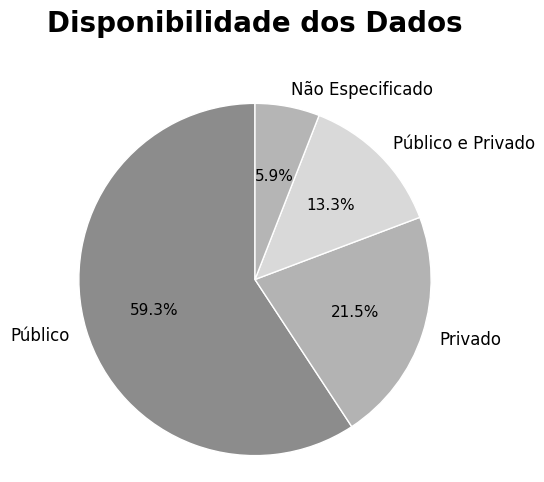

In [23]:
import numpy as np
import pandas as pd
from unidecode import unidecode
import matplotlib.pyplot as plt

# Normaliza o texto
texto = (
    Q3["Questao_10"]
    .fillna("")
    .astype(str)
    .map(unidecode)
    .str.lower()
)

# Verifica a presença das palavras
publico = texto.str.contains(r"\bpublico\w*\b", regex=True)
privado = texto.str.contains(r"\bprivado\w*\b", regex=True)

# Cria a coluna Q10_temp
Q3["Q10_temp"] = np.select(
    [
        publico & privado,
        publico,
        privado
    ],
    [
        "Público e Privado",
        "Público",
        "Privado"
    ],
    default="Não Especificado"
)

# -----------------------------
# Tabela de frequência
# -----------------------------


tabela = (
    Q3["Q10_temp"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

tabela["Percentual (%)"] = (
    tabela["Quantidade"] / TOTAL_ARTIGOS  * 100
).round(1)

print(tabela)

# -----------------------------
# Gráfico de pizza (tons de cinza)
# -----------------------------
cores = ["#8c8c8c", "#b3b3b3", "#d9d9d9", "#b5b5b5"]

plt.figure(figsize=(5,5))


wedges, texts, autotexts = plt.pie(
    tabela["Quantidade"],
    labels=tabela["Status"],
    autopct="%1.1f%%",
    startangle=90,
    colors=cores,
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 12}   # tamanho da legenda
)

# Aumenta apenas os percentuais
for autotext in autotexts:
    autotext.set_fontsize(11)
    #autotext.set_weight("bold")

plt.title(
    "Disponibilidade dos Dados",
    fontsize=20,
    fontweight="bold",
    pad=40   # distância entre o título e o gráfico
)

plt.axis("equal")

# Salvar figura
plt.savefig(
    path+"3_Graficos_Tabelas/imagens/Q2_grafico.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## **Bases Publicas e qtd de artigos**

In [24]:
Q3["Tipo_Acesso"] = (
    Q3["Q10_temp"]
    .str.contains(r"\bp[uú]blico\b", case=False, na=False)
    .astype("int8")
)
Q3_publico = Q3.loc[Q3["Tipo_Acesso"].eq(1)].copy()
Q3_publico.shape

(98, 6)

In [25]:
texto = Q3_publico["Questao_6"].fillna("").astype("string")
padroes = {
    'ADNI': r"\b.*adni.*\b",
    'Adult Income': r"\bincome\b",
    'AS-OCT NC':r"\bas oct nc\b",
    'AREDS': r"\b.*areds.*\b",
    'APTOS 2019': r"\baptos2019\b",
    'BCN20000': r"\b.*bcn20\w*\b",
    'BFW': r"\bbfw\b",
    'BraTS': r"\bbrats18\b",
    'BreakHis': r"\bbreakhis\b",
    'BTM': r"\bbtm\b",
    'CelebA': r"\bceleb\w*\b",
    'DDSM':r"\bddsm\b",
    'CHDS': r"\bchds\b",
    'Chest X Ray': r"\bchexpert|nih chestx|covid 19\b",
    'DermNet': r"\b.*dermnet.*\b",
    'Dermofit': r"\bdermofit\b",
    'DFDC': r"\bdfdc\b",
    'Duke Breast': r"\bduke breast\b",
    'EUH': r"\b.*euh.*\b",
    'EuroSAT': r"\beurosat\b",
    'FairFace': r"\bfairface\b",
    'FFDM': r"\bffdm\b",
    'Fitzpatrick17k': r"\b.*fitz\w*\b",
    'FaceForensics++': r"\bff++\b",
    'FFHQ (Flickr-Faces-HQ)': r"\bffhq flickr\b",
    'HateXplain': r"\bhatexplain\b",
    'HAM 10000': r"\bhybridequity|.*syntheticdarker.*|ham10000\b",
    'Harvard-FairSeg': r"\b.*harvard.*\b",
    'HCH': r"\b.*hch.*\b",
    'HyperKvasir': r"\bhyper kvasir\b",
    'IQ-OTH/NCCD': r"\b.*nccd.*\b",
    'ISIC': r"\bisic20\w*|isic\b",
    'Kvasir-SEG': r"\bkvasir\w*\b",
    'MedHybridEquity':r"\b.*hybridequity.*\b",
    'Med-NODE':r"\b.*med node.*\b",
    'MEPS':r"\bmeps\b",
    'MIMIC': r"\bmimic|mimic cxr\b",
    'MIRC': r"\b.*mirc.*\b",
    'MiniDomainNet': r"\bminidomainnet\b",
    'MNIST': r"\bmnist\b",
    'NHANES': r"\bnhanes\b",
    'OASIS-1': r"\boasis\b",
    'OL3I': r"\b.*ol3i.*\b",
    'PACS': r"\bpacs\b",
    'PadChest':r"\bpadchest\b",
    'PICCOLO': r"\b.*piccolo.*\b",
    'PAD-UFES-20': r"\b.*pad ufes 20.*\b",
    'Papila': r"\bpapila\b",
    'PatternNet': r"\b.*patternet.*\b",
    'PH2':r"\bph2\b",
    #'PICCOLO': r"\b.*piccolo.*\b",
    'PIPSQUEAK': r"\b.*pipsqueak.*\b",
    'ROCO Radiology': r"\broco radiology\b",
    'SD 128/198/260': r"\bsd 128|sd 198|sd 260\b",
    'SCGM':r"\bscgm\b",
    'SkinL2': r"\b.*skinl2.*\b",
    'SNU': r"\bsnu\b",
    'TCIA Breast': r"\btcia breast\b",
    'TCGA-BRCA': r"\btcga brca\b",
    'UCF Crime':r"\bucf crime\b",
    'UCI Heart Disease':r"\buci heart disease\b",
    'UCSF PDGM':r"\btcia breast\b",
    'USPS': r"\bucsf pdgm\b",
    'UTKFace': r"\butkface|utk face\b",
    'Waterbirds': r"\bwaterbirds\b",
}

for coluna, padrao in padroes.items():
    Q3_publico[coluna] = (
        texto.str.contains(
            padrao,
            regex=True,
            case=False,
            na=False,
        )
        .astype("int8")
    )

In [26]:
Q3_publico['Qtd_Bases_Utilizadas'] =  Q3_publico['ADNI'] + Q3_publico['Adult Income'] + Q3_publico['AS-OCT NC'] + Q3_publico['AREDS'] + Q3_publico['APTOS 2019'] + Q3_publico['BCN20000'] + Q3_publico['BFW'] + Q3_publico['BraTS'] + Q3_publico['BreakHis'] + Q3_publico['BTM'] + Q3_publico['CelebA'] + Q3_publico['DDSM'] + Q3_publico['CHDS'] + Q3_publico['Chest X Ray'] + Q3_publico['DermNet'] + Q3_publico['Dermofit'] + Q3_publico['DFDC'] + Q3_publico['Duke Breast'] + Q3_publico['EUH'] + Q3_publico['EuroSAT'] + Q3_publico['FairFace'] + Q3_publico['FFDM'] + Q3_publico['Fitzpatrick17k'] + Q3_publico['FaceForensics++'] + Q3_publico['FFHQ (Flickr-Faces-HQ)'] + Q3_publico['HateXplain'] + Q3_publico['HAM 10000'] + Q3_publico['Harvard-FairSeg'] + Q3_publico['HCH'] + Q3_publico['HyperKvasir'] + Q3_publico['IQ-OTH/NCCD'] + Q3_publico['ISIC'] + Q3_publico['Kvasir-SEG'] + Q3_publico['MedHybridEquity'] + Q3_publico['Med-NODE'] + Q3_publico['MEPS'] + Q3_publico['MIMIC'] + Q3_publico['MIRC'] + Q3_publico['MiniDomainNet'] + Q3_publico['MNIST'] + Q3_publico['NHANES'] + Q3_publico['OASIS-1'] + Q3_publico['OL3I'] + Q3_publico['PACS'] + Q3_publico['PadChest'] + Q3_publico['PICCOLO'] + Q3_publico['PAD-UFES-20'] + Q3_publico['Papila'] + Q3_publico['PatternNet'] + Q3_publico['PH2'] + Q3_publico['PIPSQUEAK'] + Q3_publico['ROCO Radiology'] + Q3_publico['SD 128/198/260'] + Q3_publico['SCGM'] + Q3_publico['SkinL2'] + Q3_publico['SNU'] + Q3_publico['TCIA Breast'] + Q3_publico['TCGA-BRCA'] + Q3_publico['UCF Crime'] + Q3_publico['UCI Heart Disease'] + Q3_publico['UCSF PDGM'] + Q3_publico['USPS'] + Q3_publico['UTKFace'] + Q3_publico['Waterbirds']

In [27]:
Q3_publico['Qtd_Bases_Utilizadas'].value_counts()

,count
Qtd_Bases_Utilizadas,
0,45
1,21
2,17
3,12
4,1
10,1
5,1


## **Grafico 1: Disponibilidade de Dados**

In [28]:
Q3_publico.columns

Index(['DOI', 'Nome_A', 'Questao_10', 'Questao_6', 'Q10_temp', 'Tipo_Acesso',
       'ADNI', 'Adult Income', 'AS-OCT NC', 'AREDS', 'APTOS 2019', 'BCN20000',
       'BFW', 'BraTS', 'BreakHis', 'BTM', 'CelebA', 'DDSM', 'CHDS',
       'Chest X Ray', 'DermNet', 'Dermofit', 'DFDC', 'Duke Breast', 'EUH',
       'EuroSAT', 'FairFace', 'FFDM', 'Fitzpatrick17k', 'FaceForensics++',
       'FFHQ (Flickr-Faces-HQ)', 'HateXplain', 'HAM 10000', 'Harvard-FairSeg',
       'HCH', 'HyperKvasir', 'IQ-OTH/NCCD', 'ISIC', 'Kvasir-SEG',
       'MedHybridEquity', 'Med-NODE', 'MEPS', 'MIMIC', 'MIRC', 'MiniDomainNet',
       'MNIST', 'NHANES', 'OASIS-1', 'OL3I', 'PACS', 'PadChest', 'PICCOLO',
       'PAD-UFES-20', 'Papila', 'PatternNet', 'PH2', 'PIPSQUEAK',
       'ROCO Radiology', 'SD 128/198/260', 'SCGM', 'SkinL2', 'SNU',
       'TCIA Breast', 'TCGA-BRCA', 'UCF Crime', 'UCI Heart Disease',
       'UCSF PDGM', 'USPS', 'UTKFace', 'Waterbirds', 'Qtd_Bases_Utilizadas'],
      dtype='object')

In [29]:
import pandas as pd

# Lista das colunas das bases de dados
cols = [
    'ADNI', 'PICCOLO','PatternNet','HCH','EUH','AREDS','OL3I','MIRC',
    #'Havard-GF 3300',
    'Adult Income', 'AS-OCT NC', 'APTOS 2019', 'BCN20000',
    'BFW', 'BraTS', 'BreakHis', 'BTM', 'CelebA', 'DDSM', 'CHDS',
    'Chest X Ray', 'DermNet', 'Dermofit', 'DFDC', 'Duke Breast',
    'EuroSAT', 'FairFace', 'FFDM', 'Fitzpatrick17k',
    'FaceForensics++', 'FFHQ (Flickr-Faces-HQ)', 'HateXplain',
    'HAM 10000', 'HyperKvasir', 'IQ-OTH/NCCD', 'ISIC', 'Kvasir-SEG', 'MedHybridEquity',
    'Med-NODE', 'MEPS', 'MIMIC',  'MiniDomainNet',
    'MNIST', 'NHANES', 'OASIS-1',  'PACS','PAD-UFES-20', 'Papila',  'PH2',
    'PIPSQUEAK', 'ROCO Radiology', 'SD 128/198/260',
    'SCGM', 'SkinL2', 'SNU', 'TCIA Breast', 'TCGA-BRCA',
    'UCI Heart Disease', 'UCSF PDGM', 'USPS', 'UTKFace',
    'Waterbirds'
]



# Soma das ocorrências de cada base
freq = Q3_publico[cols].sum()

# Tabela de frequência
tabela_freq = (
    pd.DataFrame({
        "Base de Dados": freq.index,
        "Frequência": freq.values.astype(int)
    })
    .assign(
        Percentual=lambda x: (x["Frequência"] / TOTAL_ARTIGOS * 100).round(1)
    )
    .sort_values("Frequência", ascending=False)
    .reset_index(drop=True)
)
tabela_freq  = tabela_freq[tabela_freq['Frequência']>0]

# Formatar percentual
tabela_freq["Percentual"] = (
    tabela_freq["Percentual"]
    .map(lambda x: f"{x:.1f}%")
)


## **Grafico 2: Qtd de Artigos por base de dados**

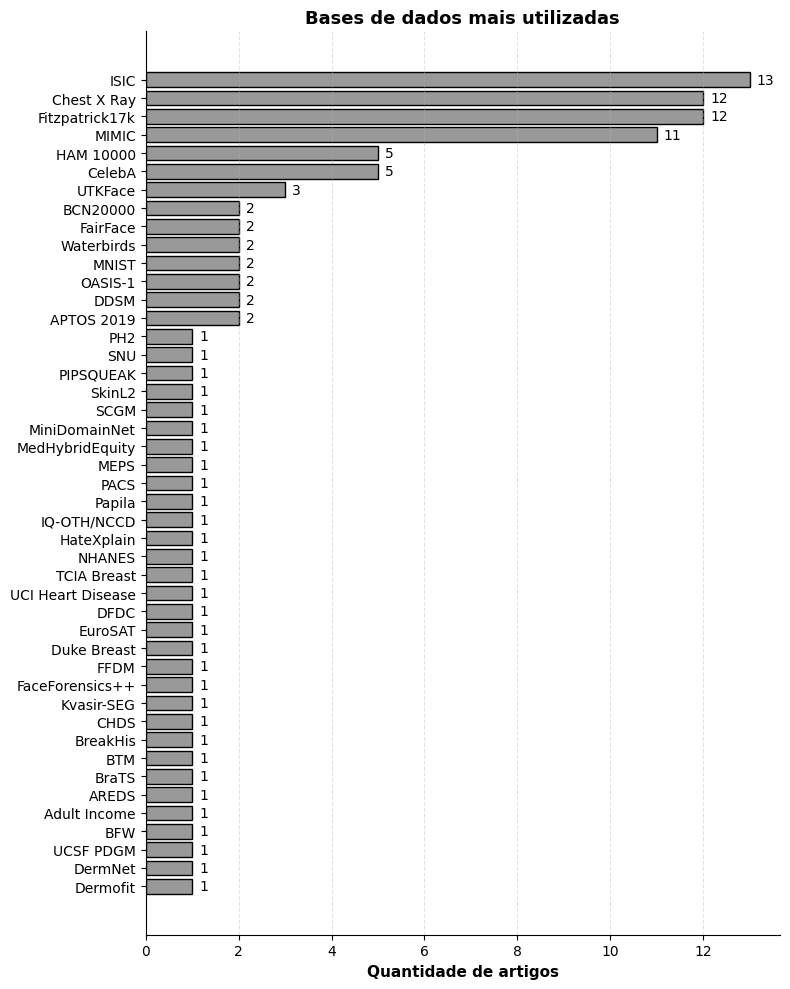

In [30]:
import matplotlib.pyplot as plt

# Considera apenas as bases com frequência > 0
graf = tabela_freq.sort_values("Frequência", ascending=True)

plt.figure(figsize=(8, 10))

bars = plt.barh(
    graf["Base de Dados"],
    graf["Frequência"],
    color="0.6",          # Cinza
    edgecolor="black"
)

# Valor ao final de cada barra
for bar in bars:
    plt.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center',
        fontsize=10
    )

plt.xlabel("Quantidade de artigos", fontsize=11, fontweight="bold")
plt.ylabel("")
plt.title("Bases de dados mais utilizadas", fontsize=13, fontweight="bold")

# Linhas de grade
plt.grid(axis='x', linestyle='--', alpha=0.35)

# Remove bordas superior e direita
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Salvar figura
plt.savefig(
    path+"3_Graficos_Tabelas/imagens/Q3_BasesDados.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [31]:
tabela_freq

,Base de Dados,Frequência,Percentual
0,ISIC,13,9.6%
1,Fitzpatrick17k,12,8.9%
2,Chest X Ray,12,8.9%
3,MIMIC,11,8.1%
4,CelebA,5,3.7%
5,HAM 10000,5,3.7%
6,UTKFace,3,2.2%
7,MNIST,2,1.5%
8,OASIS-1,2,1.5%
9,DDSM,2,1.5%


# **Questão 4 : Amostra de Dados**



```
4. Qual o tamanho da amostra de dados?
```



In [32]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import get_as_dataframe

creds, _ = default()
gc = gspread.authorize(creds)

In [33]:
sh = gc.open("Bases_Dados_Disponibilidade_Amostras")

worksheet = sh.get_worksheet(0)   # primeira aba
# worksheet = sh.get_worksheet(1) # segunda aba

df_Q4 = get_as_dataframe(
    worksheet,
    evaluate_formulas=True
)

### **Grafico 1: Dados Publicos**

In [34]:
colunas = ["Num_Amostra", "Num_Pacientes"]

df_Q4[colunas] = (
    df_Q4[colunas]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype("int64")
)
df_Q4 = df_Q4[['Base de Dados','Disponibilidade', 'Num_Amostra', 'Num_Pacientes']]

In [35]:
df_Q4_publica = df_Q4.loc[df_Q4['Disponibilidade']=='Pública']
df_Q4_privada = df_Q4.loc[df_Q4['Disponibilidade']=='Privada']

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def plotar_amostras_pacientes(df_amostra, titulo, caminho):

  figsize_largura=12
  numericas = ["Num_Amostra", "Num_Pacientes"]


  # Ordena pelo maior valor entre amostras e pacientes
  df_amostra["_ordem"] = df_amostra[numericas].max(axis=1)
  df_amostra = (
      df_amostra.sort_values("_ordem", ascending=False)
      .drop(columns="_ordem")
      .reset_index(drop=True)
  )
  y = np.arange(len(df_amostra))
  altura_barra = 0.36
  fig, ax = plt.subplots(
      figsize=(
          figsize_largura,
          max(4, len(df_amostra) * 0.3),
      )
  )

  barras_amostras = ax.barh(
      y - altura_barra / 2,
      df_amostra["Num_Amostra"],
      height=altura_barra,
      color="#888888",
      label="Amostras",
      zorder=3,
  )
  barras_pacientes = ax.barh(
      y + altura_barra / 2,
      df_amostra["Num_Pacientes"],
      height=altura_barra,
      color="#a9443a",
      label="Pacientes",
      zorder=3,
  )

  ax.set_yticks(y)
  ax.set_yticklabels(df_amostra["Base de Dados"])
  ax.invert_yaxis()
  ax.set_title(
      titulo,
      fontsize=16,
      fontweight="bold",
      pad=12,
  )
  ax.set_xlabel("Volumetria", fontsize=12)
  ax.set_ylabel("Base de Dados", fontsize=12)
  ax.grid(
      axis="x",
      linestyle="--",
      linewidth=0.8,
      alpha=0.35,
      zorder=1,
  )
  ax.xaxis.set_major_formatter(
      FuncFormatter(
          lambda valor, _: f"{valor:,.0f}".replace(",", ".")
      )
  )
  ax.legend(loc="lower right")
  fig.tight_layout()

  # Salvar figura
  plt.savefig(
      caminho,
      dpi=300,
      bbox_inches="tight",
      facecolor="white"
  )

  return fig, ax

/tmp/ipykernel_65781/3540197014.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_amostra["_ordem"] = df_amostra[numericas].max(axis=1)


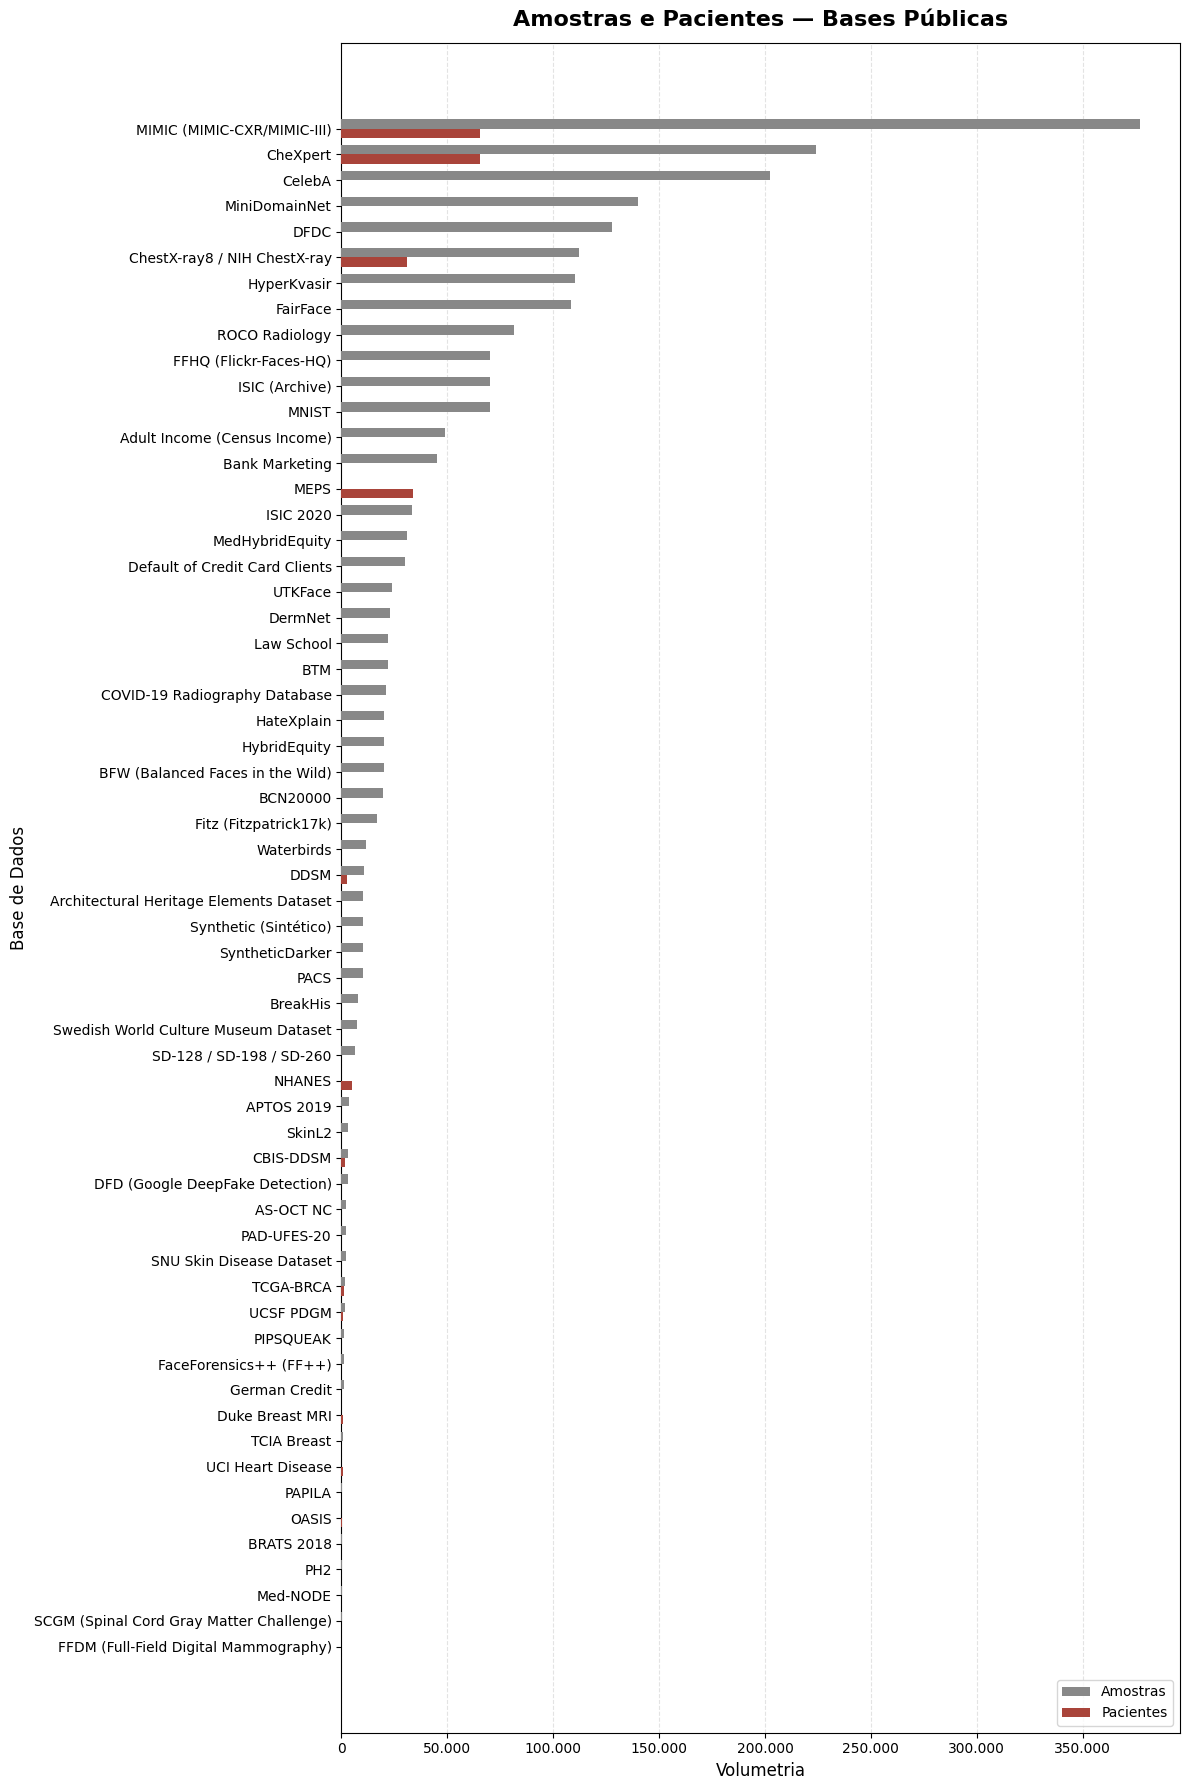

In [37]:
caminho = path+"3_Graficos_Tabelas/imagens/Q4_TamanhoAmostra_Publica.png"
fig_publico, ax_publico = plotar_amostras_pacientes(df_Q4_publica, "Amostras e Pacientes — Bases Públicas", caminho)
plt.show()

In [38]:
# Artigos que citam a base de dados MIMIC
artigo_mimic = Q3_publico[['DOI', 'Nome_A', 'Questao_10', 'Questao_6', 'Q10_temp', 'Tipo_Acesso','MIMIC']]
artigo_mimic = artigo_mimic.loc[artigo_mimic['MIMIC'].eq(1)]
artigo_mimic.head()

,DOI,Nome_A,Questao_10,Questao_6,Q10_temp,Tipo_Acesso,MIMIC
32,10.1109/EMBC53108.2024.10782563,IMPROVING FAIRNESS IN CHEST X RAY INTERPRETATION MODELS USING ATTENTION DRIVEN MASKED IMAGE MODELING,publico,MIMIC CXR dataset\nImagens de raio-X de tórax (Chest X-Ray – CXR),Público,1,1
41,-1,TRANSFERRING FAIRNESS USING MULTI TASK LEARNING WITH LIMITED DEMOGRAPHIC INFORMATION,publico e privado,"MIMIC-III (registros clínicos), Trustpilot (reviews online), Twitter (dados de mídia social), HateXplain",Público e Privado,1,1
65,10.12688/f1000research.166307.2,EXPLAINABLE TRANSFER LEARNING WITH RESIDUAL ATTENTION BILSTM FOR PROGNOSIS OF ISCHEMIC HEART DISEASE,publico,UCI Heart Disease Dataset; MIMIC-III,Público,1,1
81,10.1007/978-3-032-04981-0_22,EXPOSING AND MITIGATING CALIBRATION BIASES AND DEMOGRAPHIC UNFAIRNESS IN MLLM FEW SHOT IN CONTEXT LEARNING FOR MEDICAL IMAGE CLASSIFICATION,publico,"PAPILA, HAM10000, MIMIC-CXR",Público,1,1
92,10.1016/j.media.2025.103858,FAIRREAD: RE FUSING DEMOGRAPHIC ATTRIBUTES AFTER DISENTANGLEMENT FOR FAIR MEDICAL IMAGE CLASSIFICATION,publico,CheXpert (dataset de radiografias de tórax)\nMIMIC-CXR (para avaliação out-of-distribution),Público,1,1


In [39]:
# Artigos que citam a base de dados CelebA
artigo_CelebA = Q3_publico[['DOI', 'Nome_A', 'Questao_10', 'Questao_6', 'Q10_temp', 'Tipo_Acesso','CelebA']]
artigo_CelebA = artigo_CelebA.loc[artigo_CelebA['CelebA'].eq(1)]
artigo_CelebA.head()

,DOI,Nome_A,Questao_10,Questao_6,Q10_temp,Tipo_Acesso,CelebA
30,10.1109/JSTSP.2024.3363419,FAIRTL: A TRANSFER LEARNING APPROACH FOR BIAS MITIGATION IN DEEP GENERATIVE MODELS,publicos,"FFHQ (Flickr-Faces-HQ) – Conjunto de imagens faciais de alta qualidade.\nCelebA-HQ – Conjunto de imagens faciais de celebridades com atributos anotados, como gênero e raça.\nUTKFace – Banco de dados com informações sobre idade, gênero e etnia.",Público,1,1
58,-1,TO TRANSFER OR NOT TO TRANSFER: SUPPRESSING CONCEPTS FROM SOURCE REPRESENTATIONS,publico,MNIST\nEMNIST\nCelebA (CelebFaces Attributes)\nWaterBirds\nCDC Diabetes Health Indicators Dataset,Público,1,1
104,10.1145/3746252.3761306,MMFAIR: FAIR LEARNING VIA MIN MIN OPTIMIZATION,publico,Waterbirds\nCelebA\nISIC,Público,1,1
140,-1,PRESERVING AUC FAIRNESS IN LEARNING WITH NOISY PROTECTED GROUPS,publico,"Adult, Bank, Default, FF++, DFDC, DFD, Celeb-DF",Público,1,1
148,10.1109/ACCESS.2024.3383841,FAIRNESS MEETS CROSS DOMAIN LEARNING: A BENCHMARK OF MODELS AND METRICS,publicos,Base de Dados CelebA: imagens de rostos de celebridades\r\nCOVID-19 Chest X-Ray: imagens de raios-X de tórax\r\nFitzpatrick17k: imagens clínicas de condições dermatológicas\r\nUTK Face: imagens de rostos,Público,1,1


In [40]:
# Percentual de Artigos que não informam a quantidade de pacientes,
((df_Q4_publica[df_Q4_publica['Num_Pacientes'].eq(0)].shape[0]) / (df_Q4_publica.shape[0])) * 100


80.0

### **Grafico 2: Dados Privados**

/tmp/ipykernel_65781/3540197014.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_amostra["_ordem"] = df_amostra[numericas].max(axis=1)


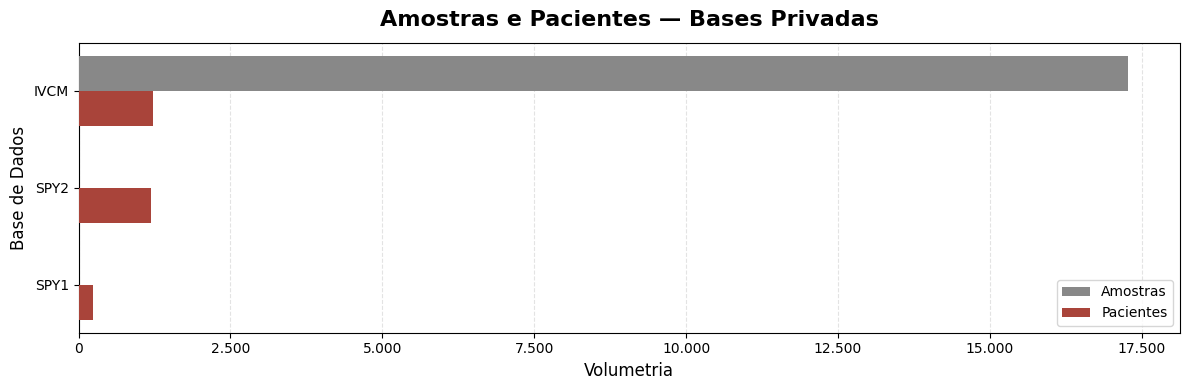

In [41]:
caminho = path+"3_Graficos_Tabelas/imagens/Q4_TamanhoAmostra_Privada.png"
fig_privada, ax_privada = plotar_amostras_pacientes( df_Q4_privada, "Amostras e Pacientes — Bases Privadas",caminho)
plt.show()

In [42]:
Q3_privada = Q3.loc[Q3["Tipo_Acesso"].eq(0)].copy()

In [43]:
# Artigos que citam a base de dados IVCM
# Localiza as linhas em que a coluna Questao_6 contém “IVCM”
linhas_ivcm = Q3_privada[
    Q3_privada["Questao_6"]
    .fillna("")
    .str.contains(r"\bIVCM\b", case=False, regex=True)
]
linhas_ivcm

,DOI,Nome_A,Questao_10,Questao_6,Q10_temp,Tipo_Acesso
1,10.1016/j.jtos.2024.08.002,DEEP LEARNING BASED ANALYSIS OF IN VIVO CONFOCAL MICROSCOPY IMAGES OF THE SUBBASAL CORNEAL NERVE PLEXUS' INFERIOR WHORL IN PATIENTS WITH NEUROPATHIC CORNEAL PAIN AND DRY EYE DISEASE,privados,Dados clinicos e Imagens obtidas por microscopia confocal in vivo (IVCM),Privado,0
132,10.18280/isi.310313,"CRITICAL ASSESSMENT OF DCGAN BASED DATA BALANCING IN DEEP LEARNING FOR KERATITIS IDENTIFICATION: TRADE OFF BETWEEN FIDELITY, FAIRNESS, AND PERFORMANCE",privado,Imagens de microscopia confocal in vivo (IVCM) da córnea\nImagens sintéticas geradas por DCGAN (GAN) para balanceamento das classes,Privado,0


In [44]:
Q3_privada

,DOI,Nome_A,Questao_10,Questao_6,Q10_temp,Tipo_Acesso
1,10.1016/j.jtos.2024.08.002,DEEP LEARNING BASED ANALYSIS OF IN VIVO CONFOCAL MICROSCOPY IMAGES OF THE SUBBASAL CORNEAL NERVE PLEXUS' INFERIOR WHORL IN PATIENTS WITH NEUROPATHIC CORNEAL PAIN AND DRY EYE DISEASE,privados,Dados clinicos e Imagens obtidas por microscopia confocal in vivo (IVCM),Privado,0
2,10.1038/s41598-023-42719-5,APPLICATION OF SERUM SERS TECHNOLOGY COMBINED WITH DEEP LEARNING ALGORITHM IN THE RAPID DIAGNOSIS OF IMMUNE DISEASES AND CHRONIC KIDNEY DISEASE,privados,Amostras de sangue\r\nEspectros SERS (Surface-Enhanced Raman Spectroscopy)\r\nDados demográficos\r\nDados gerados,Privado,0
3,10.1016/j.bspc.2026.109615,DIAGNOSTIC PERFORMANCE OF DEEP LEARNING MODELS USING PAROTID GLAND ULTRASONOGRAPHY IN SJOGREN'S DISEASE,privado,Imagens de ultrassonografia das glândulas parótidas \n,Privado,0
4,10.3390/diagnostics13142373,DETECTION OF HYDROXYCHLOROQUINE RETINOPATHY VIA HYPERSPECTRAL AND DEEP LEARNING THROUGH OPHTHALMOSCOPE IMAGES,privados,Imagens oftalmoscópicas hiperespectrais,Privado,0
5,10.1007/s10067-025-07518-5,ARTIFICIAL INTELLIGENCE BASED PREDICTION OF ORGAN INVOLVEMENT IN SJOGREN'S SYNDROME USING LABIAL GLAND BIOPSY WHOLE SLIDE IMAGES,privado,Imagens de lâminas inteiras (WSI) de biópsia de glândula labial\nPatches extraídos das WSI\nDados clínicos dos pacientes (envolvimento de órgãos),Privado,0
6,10.1259/dmfr.20190348,USEFULNESS OF A DEEP LEARNING SYSTEM FOR DIAGNOSING SJOGREN'S SYNDROME USING ULTRASONOGRAPHY IMAGES,privados,imagens de ultrassom (US) das glândulas salivares,Privado,0
8,10.1109/BIBE52308.2021.9635506,SCORING PRIMARY SJOGREN'S SYNDROME AFFECTED SALIVARY GLANDS ULTRASONOGRAPHY IMAGES BY USING DEEP LEARNING ALGORITHMS,privados,1. Dados principais: Imagens de ultrassom das glândulas salivares.\r\n2. Rótulos: Escoragem clínica baseada em padrões de referência estabelecidos.\r,Privado,0
9,10.1186/s13000-026-01756-0,SJOGREN'S SYNDROME FOCUSASSIST: LYMPHOCYTIC FOCUS ASSESSMENT IN SJOGREN'S SYNDROME: A DEEP LEARNING AND SPATIAL ANALYSIS APPROACH,privado,Lâminas histopatológicas coradas com H&E (biópsias de glândulas salivares labiais)\nImagens digitais de lâminas (whole-slide images – WSI)\nSeções/patches de imagem (512×512 pixels)\nAnotações celulares (nível de linfócitos)\nAnotações de lesões (nível de focos linfocíticos)\nResultados de exames laboratoriais imunológicos dos pacientes \n,Privado,0
10,10.1259/dmfr.20190019,PRELIMINARY STUDY ON THE APPLICATION OF DEEP LEARNING SYSTEM TO DIAGNOSIS OF SJOGREN'S SYNDROME ON CT IMAGES,privados,tomografia computadorizada (CT),Privado,0
11,10.1016/j.jaut.2025.103418,EVALUATION OF MINOR LABIAL SALIVARY GLAND FOCUS SCORE IN SJOGREN'S DISEASE USING DEEP LEARNING: A TOOL FOR MORE EFFICIENT DIAGNOSIS AND FUTURE TISSUE BIOMARKER DISCOVERY,privado,Biópsias de glândulas salivares labiais menores (imagens histopatológicas),Privado,0


In [45]:
Q4_SPY = df.loc[:, ["DOI", "Nome_A", "Questao_10","Questao_6","Questao_12"]].copy()

In [46]:
# Transforma a coluna Questao_6 em letras minúsculas
Q4_SPY["Questao_12"] = Q4_SPY["Questao_12"].fillna("").str.lower()

# Localiza as linhas que contêm “spy1” ou “spy2”
linhas_SPY = Q4_SPY[
    Q4_SPY["Questao_6"].str.contains(
        r"\bspy[12]\b",
        regex=True,
        case=False,
        na=False
    )
]

linhas_SPY

,DOI,Nome_A,Questao_10,Questao_6,Questao_12
64,10.1007/978-3-032-05559-0_31,ON TACKLING DOMAIN SHIFT IN BREAST MRI USING ONLY PUBLICLY AVAILABLE DATA: REPRODUCIBLE BREAST CANCER SEGMENTATION AND PCR PREDICTION,Público,Duke Breast Cancer MRI dataset\nTCIA Breast MRI collections\nI-SPY1 Trial dataset\nI-SPY2 Trial dataset,imagens de ressonância magnética (mri)\ndados clínicos/tabulares


# **Questão 5: Atributos Sensiveis**



```
5. A base de dados tem atributos sensíveis?
```



In [47]:
Q5 = df.loc[:, ["DOI", "Nome_A", "Questao_8"]].copy()

In [48]:
texto = Q5["Questao_8"].fillna("").astype("string").str.lower()
padroes = {
    "Idade": r"\bidade\b",
    "Gênero": r"\bgenero|gênero|sexo|male\b",
    "Etnia/Raça": r"\bAncestralidade|etnia|raça\b",
    "Sem atributos sensiveis": r"\bsem atributos|nao|não\b",
}

for coluna, padrao in padroes.items():
    # Converte (...) em (?:...), preservando grupos especiais como (?=...)
    padrao_sem_captura = re.sub(
        r"(?<!\\)\((?!\?)",
        "(?:",
        padrao,
    )

    Q5.loc[:, coluna] = (
        texto.str.contains(
            padrao_sem_captura,
            regex=True,
            case=False,
            na=False,
        )
        .astype("int8")
    )

pd.set_option("display.max_colwidth", None)

In [49]:
# Cria a coluna "Não mencionado":
# 1 quando a soma de Idade, Gênero e Etnia/Raça for menor que 1;
# 0 nos demais casos.

Q5["Não mencionado"] = (
    Q5[["Idade", "Gênero", "Etnia/Raça"]].sum(axis=1)
    .map(lambda x: 1 if x < 1 else 0)
)

Q5_graf = Q5[["Idade", "Gênero", "Etnia/Raça","Não mencionado"]]
resumo = (
    Q5_graf
    .sum()
    .rename("Total")
    .reset_index()
    .rename(columns={"index": "Categoria"})
)
resumo["Percentual"] = (resumo["Total"] / TOTAL_ARTIGOS * 100).round(1)
resumo = resumo.sort_values("Total", ascending=False)
resumo

,Categoria,Total,Percentual
1,Gênero,75,55.6
0,Idade,63,46.7
3,Não mencionado,54,40.0
2,Etnia/Raça,37,27.4


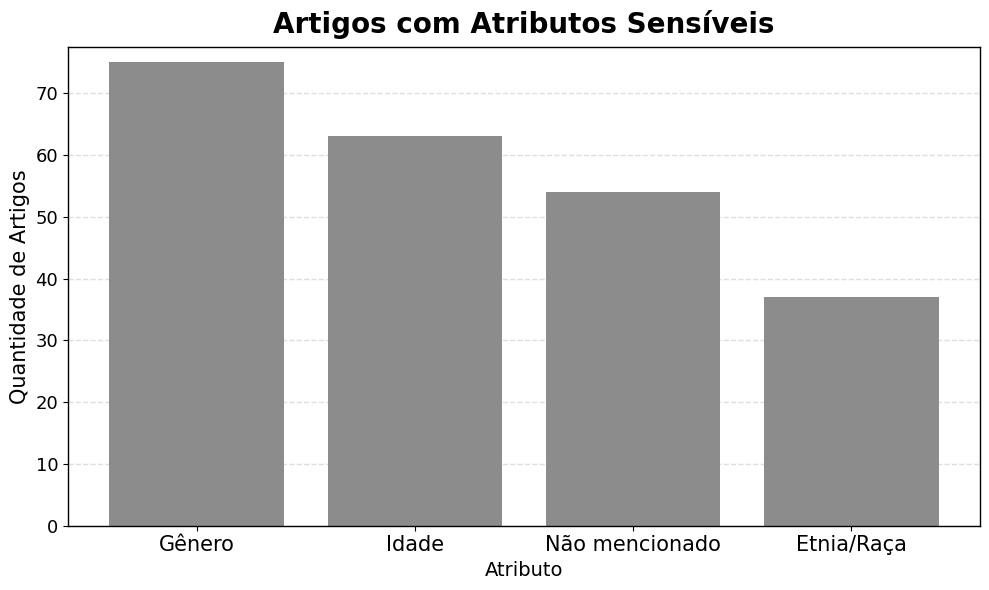

In [50]:
# Mantém as barras em ordem decrescente
resumo_grafico = resumo.sort_values("Total", ascending=False)

# Cria o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    resumo_grafico["Categoria"],
    resumo_grafico["Total"],
    color="#8c8c8c",
    width=0.8
)

ax.set_title(
    "Artigos com Atributos Sensíveis",
    fontsize=20,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Atributo", fontsize=14)
ax.set_ylabel("Quantidade de Artigos", fontsize=15)

# Linhas horizontais tracejadas
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=1,
    alpha=0.4
)
ax.set_axisbelow(True)

# Configura os limites e as marcações do eixo Y
maior_total = resumo_grafico["Total"].max()
limite_y = int(np.ceil(maior_total / 4) * 4)

ax.set_ylim(0, limite_y + 1.5)
ax.set_yticks(np.arange(0, limite_y + 2, 10))

ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=13)

# Define a espessura das bordas
for borda in ax.spines.values():
    borda.set_linewidth(1)

# Salvar figura
plt.savefig(
    path+"3_Graficos_Tabelas/imagens/Q5_AtributosSensiveis.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.tight_layout()
plt.show()

In [51]:
Q5_graf = Q5[["Idade", "Gênero", "Etnia/Raça","Não mencionado"]]
resumo = (
    Q5_graf
    .sum()
    .rename("Total")
    .reset_index()
    .rename(columns={"index": "Categoria"})
)
resumo["Percentual"] = (resumo["Total"] / TOTAL_ARTIGOS * 100).round(1)
resumo = resumo.sort_values("Total", ascending=False)
resumo

,Categoria,Total,Percentual
1,Gênero,75,55.6
0,Idade,63,46.7
3,Não mencionado,54,40.0
2,Etnia/Raça,37,27.4


# **Questão 6**



```
6. Qual a tarefa de aprendizado realizada? Classificação ou segmentação?
```



# **Questão 4**

# **Questão 4**

# **Questão 4**

# **Questão 4**

# **Questão 4**

# **Questão 4**

# **Questão 4**

# **Questão 4**

# **Questão 4**

# **Questão 4**